# EU Progress Report Scoring Pipeline
End-to-end demo: raw scraped text → paragraph corpus → criticism scores → country-year summary + plots.

## Step 1 — Build paragraph corpus

In [1]:
from corpus import build_corpus

df = build_corpus("scraped/raw", min_words=50, max_words=500)

print(f"Total paragraphs : {len(df):,}")
print(f"Countries        : {sorted(df['country'].unique())}")
print(f"Years            : {sorted(df['year'].unique())}")
df.head(3)

  Albania                   2019  →  444 paragraphs
  Albania                   2020  →  547 paragraphs
  Albania                   2021  →  576 paragraphs
  Albania                   2022  →  538 paragraphs
  Albania                   2023  →  591 paragraphs
  Albania                   2024  →  363 paragraphs
  Albania                   2025  →  376 paragraphs
  Bosnia And Herzegovina    2020  →  497 paragraphs
  Bosnia And Herzegovina    2021  →  519 paragraphs
  Bosnia And Herzegovina    2022  →  548 paragraphs
  Bosnia And Herzegovina    2023  →  591 paragraphs
  Bosnia And Herzegovina    2024  →  368 paragraphs
  Bosnia And Herzegovina    2025  →  394 paragraphs
  Georgia                   2023  →  522 paragraphs
  Georgia                   2024  →  362 paragraphs
  Georgia                   2025  →  290 paragraphs
  Kosovo                    2019  →  395 paragraphs
  Kosovo                    2020  →  481 paragraphs
  Kosovo                    2021  →  457 paragraphs
  Kosovo    

,country,year,paragraph_id,paragraph_text,word_count
0,Albania,2019,0,Democracy 6 2.1.2. Public administration re...,72
1,Albania,2019,1,Albania has continued to implement the Stabili...,115
2,Albania,2019,2,Parliamentary activities were affected by a pr...,94


### Paragraph size distribution

count    26764.0
mean       107.9
std         69.8
min         50.0
25%         66.0
50%         88.0
75%        125.0
max        811.0


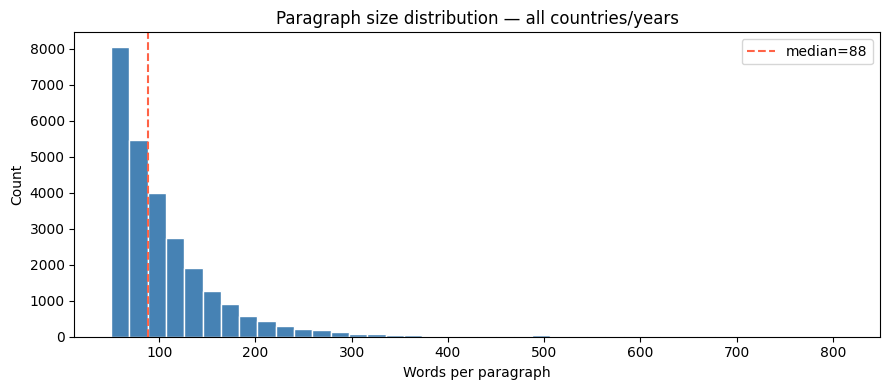

In [2]:
import matplotlib.pyplot as plt

wc = df["word_count"]
print(wc.describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(wc, bins=40, color="steelblue", edgecolor="white")
ax.axvline(wc.median(), color="tomato", linestyle="--", label=f"median={wc.median():.0f}")
ax.set_xlabel("Words per paragraph")
ax.set_ylabel("Count")
ax.set_title("Paragraph size distribution — all countries/years")
ax.legend()
plt.tight_layout()
plt.show()

## Step 2 — Score paragraphs

In [3]:
from score import score_corpus

df_scored = score_corpus(df)

print(f"Paragraphs with any hard criticism : {(df_scored['criticism_hard_p1k'] > 0).sum():,}")
print(f"Paragraphs with any soft criticism : {(df_scored['criticism_soft_p1k'] > 0).sum():,}")
print(f"Paragraphs with severity score     : {df_scored['severity_ratio'].notna().sum():,}")
df_scored[["country","year","paragraph_id","word_count",
           "criticism_hard_p1k","criticism_soft_p1k","severity_ratio"]].head(5)

Paragraphs with any hard criticism : 4,620
Paragraphs with any soft criticism : 17,833
Paragraphs with severity score     : 17,833


,country,year,paragraph_id,word_count,criticism_hard_p1k,criticism_soft_p1k,severity_ratio
0,Albania,2019,0,72,0.0,0.0,NaN
1,Albania,2019,1,115,0.0,0.0,NaN
2,Albania,2019,2,94,0.0,0.0,NaN
3,Albania,2019,3,95,0.0,0.0,NaN
4,Albania,2019,4,171,0.0,0.0,NaN


## Step 3 — Aggregate to country-year level

In [4]:
from score import aggregate_country_year

agg = aggregate_country_year(df_scored)
print(agg.to_string(index=False))

               country  year  criticism_hard_p1k  criticism_soft_p1k  severity_ratio
               Albania  2019              1.4618             21.3927          0.0723
               Albania  2020              1.2345             20.1961          0.0657
               Albania  2021              1.2019             19.1759          0.0561
               Albania  2022              1.2767             22.1027          0.0681
               Albania  2023              1.5470             25.5129          0.0670
               Albania  2024              1.3549             24.3694          0.0567
               Albania  2025              2.0698             27.4993          0.0887
Bosnia And Herzegovina  2020              3.8650             28.1994          0.1830
Bosnia And Herzegovina  2021              3.8327             28.8028          0.1426
Bosnia And Herzegovina  2022              3.4687             27.8572          0.1653
Bosnia And Herzegovina  2023              3.1847             28.5

## Step 4 — Plots

In [5]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

all_countries = sorted(agg["country"].unique())
colors = {c: cm.tab10(i / len(all_countries)) for i, c in enumerate(all_countries)}

country_selector = widgets.SelectMultiple(
    options=all_countries,
    value=all_countries,
    description="Countries",
    layout=widgets.Layout(width="220px", height="180px"),
)

out = widgets.Output()

def plot(selected):
    out.clear_output(wait=True)
    with out:
        if not selected:
            print("Select at least one country.")
            return
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle("Criticism Scores by Country-Year", fontsize=13, fontweight="bold")

        def line_plot(ax, col, title, ylabel):
            for country in selected:
                d = agg[agg["country"] == country].sort_values("year")
                ax.plot(d["year"], d[col], marker="o", label=country, color=colors[country])
            ax.set_title(title, fontsize=11)
            ax.set_ylabel(ylabel)
            ax.set_xlabel("Year")
            ax.legend(fontsize=7, ncol=2)
            ax.grid(True, alpha=0.3)

        line_plot(axes[0], "criticism_hard_p1k", "Hard Criticism",  "score p1k")
        line_plot(axes[1], "criticism_soft_p1k", "Soft Criticism",  "score p1k")
        line_plot(axes[2], "severity_ratio",      "Severity Ratio",  "hard / soft")

        plt.tight_layout()
        plt.show()

widgets.interactive_output(plot, {"selected": country_selector})
display(widgets.HBox([country_selector, out]))
plot(all_countries)

## Step 4b — Topic tagging

In [6]:
from score import tag_topics

df_scored = tag_topics(df_scored)

topic_cols = [c for c in df_scored.columns if c.startswith("topic_")]
topic_counts = df_scored[topic_cols].sum().rename(lambda c: c.replace("topic_", ""))

print("Paragraphs flagged per topic (corpus-wide):")
print(topic_counts.to_string())
print()
print(f"Paragraphs with at least one topic : {df_scored[topic_cols].any(axis=1).sum():,}")
print(f"Paragraphs with no topic match     : {(~df_scored[topic_cols].any(axis=1)).sum():,}")
print()
print(f"Mean topics per paragraph          : {df_scored[topic_cols].sum(axis=1).mean():.2f}")
df_scored[topic_cols].head(5)

Paragraphs flagged per topic (corpus-wide):
judiciary_rule_of_law                5613
corruption_anti_corruption           3410
public_administration_governance     4110
political_functioning               10847
economy_market                       7594

Paragraphs with at least one topic : 19,766
Paragraphs with no topic match     : 6,998

Mean topics per paragraph          : 1.18


,topic_judiciary_rule_of_law,topic_corruption_anti_corruption,topic_public_administration_governance,topic_political_functioning,topic_economy_market
0,True,False,True,True,True
1,True,False,False,False,False
2,False,False,False,True,False
3,True,False,False,False,False
4,True,True,False,True,False


## Step 4c — Topic-level criticism scores

In [7]:
from score import aggregate_by_topic
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ipywidgets as widgets
from IPython.display import display

agg_topic = aggregate_by_topic(df_scored)

print(f"Rows: {len(agg_topic)}  (country × year × topic)")
agg_topic.head(10)

Rows: 285  (country × year × topic)


,country,year,topic,n_paragraphs,criticism_hard_p1k,criticism_soft_p1k,severity_ratio
0,Albania,2019,judiciary_rule_of_law,76,2.0398,21.7310,0.0786
1,Albania,2020,judiciary_rule_of_law,90,2.0471,19.7111,0.0949
2,Albania,2021,judiciary_rule_of_law,96,1.4931,18.8815,0.0807
3,Albania,2022,judiciary_rule_of_law,94,1.1907,18.5737,0.0666
4,Albania,2023,judiciary_rule_of_law,108,1.8692,23.1949,0.0682
5,Albania,2024,judiciary_rule_of_law,61,3.8060,26.1454,0.1539
6,Albania,2025,judiciary_rule_of_law,60,5.6669,28.8197,0.2100
7,Bosnia And Herzegovina,2020,judiciary_rule_of_law,104,5.4936,32.6192,0.2306
8,Bosnia And Herzegovina,2021,judiciary_rule_of_law,113,6.5303,31.7473,0.2145
9,Bosnia And Herzegovina,2022,judiciary_rule_of_law,120,5.1005,25.2400,0.2215


In [ ]:
# --- Interactive heatmap: pick metric and year ---
all_topics    = sorted(agg_topic["topic"].unique())
all_countries = sorted(agg_topic["country"].unique())
all_years     = sorted(agg_topic["year"].unique())

metric_selector = widgets.Dropdown(
    options=[
        ("Hard criticism",  "criticism_hard_p1k"),
        ("Soft criticism",  "criticism_soft_p1k"),
        ("Severity ratio",  "severity_ratio"),
    ],
    value="criticism_hard_p1k",
    description="Metric:",
    layout=widgets.Layout(width="260px"),
)

year_selector = widgets.SelectMultiple(
    options=all_years,
    value=all_years,
    description="Years:",
    layout=widgets.Layout(width="160px", height="160px"),
)

country_selector = widgets.SelectMultiple(
    options=all_countries,
    value=all_countries,
    description="Countries:",
    layout=widgets.Layout(width="220px", height="160px"),
)

out = widgets.Output()

def draw(metric, years, countries):
    out.clear_output(wait=True)
    with out:
        sub = agg_topic[
            agg_topic["year"].isin(years) &
            agg_topic["country"].isin(countries)
        ].copy()

        sub["country_year"] = sub["country"] + " (" + sub["year"].astype(str) + ")"
        pivot = sub.pivot_table(index="topic", columns="country_year", values=metric)

        fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns) * 0.9), 4))
        im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([t.replace("_", " ") for t in pivot.index], fontsize=9)
        ax.set_title(f"{metric}  by topic x country-year", fontsize=11)
        plt.tight_layout()
        plt.show()

widgets.interactive_output(draw, {"metric": metric_selector, "years": year_selector, "countries": country_selector})
controls = widgets.HBox([metric_selector, year_selector, country_selector])
display(controls, out)
draw(metric_selector.value, all_years, all_countries)

Output()

## Step 5 — Save outputs

In [9]:
from pathlib import Path
Path("data").mkdir(exist_ok=True)

df.to_csv("data/paragraphs.csv", index=False)
df_scored.to_csv("data/scores.csv", index=False)
agg.to_csv("data/summary.csv", index=False)

print("Saved:")
print(f"  data/paragraphs.csv  ({len(df):,} rows)")
print(f"  data/scores.csv      ({len(df_scored):,} rows)")
print(f"  data/summary.csv     ({len(agg):,} rows)")

Saved:
  data/paragraphs.csv  (26,764 rows)
  data/scores.csv      (26,764 rows)
  data/summary.csv     (57 rows)


## Step 6 — Logistic regression: predictors of hard criticism

**DV:** `hard_flag` — whether a paragraph contains any hard criticism (binary)  
**IVs:** topic dummies · `year` (linear trend) · country fixed effects

Each observation is a paragraph. Countries are modelled as fixed effects (dummies); one country is the reference category. `year` enters as a continuous variable to capture a linear time trend.

> Note: paragraphs can belong to multiple topics simultaneously, so topic dummies are included side-by-side (not mutually exclusive).

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ── 1. Build regression dataset ─────────────────────────────────────────────
reg = df_scored.copy()

# Binary DV
reg["hard_flag"] = (reg["criticism_hard_p1k"] > 0).astype(int)

# Topic columns
topic_cols = [c for c in reg.columns if c.startswith("topic_")]
for c in topic_cols:
    reg[c] = reg[c].astype(int)

# Short topic names for display
topic_labels = {c: c.replace("topic_", "").replace("_", " ") for c in topic_cols}

# Centre year so the intercept is meaningful
reg["year_c"] = reg["year"] - reg["year"].median()

# Reference country: Albania (first alphabetically)
ref_country = sorted(reg["country"].unique())[0]
print(f"Reference country : {ref_country}")
print(f"Reference year    : {reg['year'].median():.0f} (year_c = 0)")
print(f"N paragraphs      : {len(reg):,}")
print(f"Hard-flag rate    : {reg['hard_flag'].mean():.1%}\n")

# ── 2. Fit logistic regression ───────────────────────────────────────────────
topic_terms = " + ".join(topic_cols)
formula = f"hard_flag ~ {topic_terms} + year_c + C(country, Treatment('{ref_country}'))"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model = smf.logit(formula, data=reg).fit(disp=False)

print(model.summary2())


In [ ]:
# ── 3. Odds-ratio plot ───────────────────────────────────────────────────────
res = pd.DataFrame({
    "coef": model.params,
    "lower": model.conf_int()[0],
    "upper": model.conf_int()[1],
    "pval":  model.pvalues,
}).drop("Intercept")

# Exponentiate → odds ratios
or_df = np.exp(res)
or_df["pval"] = res["pval"]
or_df["sig"]  = or_df["pval"] < 0.05

# ── 3a. Topic & time coefficients ───────────────────────────────────────────
topic_time_mask = or_df.index.str.startswith("topic_") | or_df.index.str.startswith("year_c")
tt = or_df[topic_time_mask].copy()

# Clean labels
def clean_label(s):
    s = s.replace("topic_", "").replace("_", " ")
    s = s.replace("year c", "year (linear trend)")
    return s

tt.index = [clean_label(i) for i in tt.index]

fig, ax = plt.subplots(figsize=(7, len(tt) * 0.55 + 1))
colors = ["steelblue" if s else "lightgrey" for s in tt["sig"]]
ax.barh(tt.index, tt["coef"] - 1, left=1, color=colors, edgecolor="white", height=0.6)
ax.errorbar(
    tt["coef"], range(len(tt)),
    xerr=[tt["coef"] - tt["lower"], tt["upper"] - tt["coef"]],
    fmt="none", color="black", capsize=3, linewidth=1,
)
ax.axvline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Odds ratio  (reference: Albania, year = 2022)")
ax.set_title("Topic & time predictors of hard criticism\n(blue = p < 0.05)", fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── 3b. Country fixed effects ────────────────────────────────────────────────
country_mask = or_df.index.str.startswith("C(country")
ct = or_df[country_mask].copy()
ct.index = ct.index.str.extract(r"T\.(.+?)\]")[0].values

ct = ct.sort_values("coef")

fig, ax = plt.subplots(figsize=(7, len(ct) * 0.55 + 1))
colors = ["tomato" if s else "lightgrey" for s in ct["sig"]]
ax.barh(ct.index, ct["coef"] - 1, left=1, color=colors, edgecolor="white", height=0.6)
ax.errorbar(
    ct["coef"], range(len(ct)),
    xerr=[ct["coef"] - ct["lower"], ct["upper"] - ct["coef"]],
    fmt="none", color="black", capsize=3, linewidth=1,
)
ax.axvline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Odds ratio  (reference: Albania)")
ax.set_title("Country fixed effects on hard criticism\n(red = p < 0.05)", fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── 4. Summary table (odds ratios + CI + p) ──────────────────────────────────
summary = or_df[["coef","lower","upper","pval"]].rename(columns={
    "coef": "Odds Ratio", "lower": "CI 2.5%", "upper": "CI 97.5%", "pval": "p-value"
})
summary.index = [
    clean_label(i) if not i.startswith("C(country") else
    "country: " + i.split("T.")[1].rstrip("]")
    for i in or_df.index
]
summary.round(3)


## Step 7 — Robustness checks

Three checks on the base logistic regression:

1. **Clustered standard errors** — re-use the fitted model but cluster SEs by country, since paragraphs from the same country are correlated
2. **Kosovo × topic interactions** — adds `Kosovo dummy × each topic` to test whether Kosovo's excess hard criticism is concentrated in specific topics
3. **Severity ratio as DV** (OLS, clustered) — replaces the binary flag with `severity_ratio` (hard / soft) among paragraphs that have any soft criticism, testing whether Kosovo also gets *harsher* language, not just more of it

CHECK 1 — Clustered vs default SEs (topic & time terms)
                                     OR  SE (default)  SE (clustered)  p (default)  p (clustered)
judiciary rule of law             1.867         0.038           0.089        0.000          0.000
corruption anti corruption        1.581         0.045           0.050        0.000          0.000
public administration governance  1.126         0.045           0.046        0.008          0.010
political functioning             1.304         0.033           0.058        0.000          0.000
economy market                    0.880         0.039           0.058        0.001          0.026
year trend                        1.002         0.009           0.011        0.860          0.880 

CHECK 2 — Kosovo × topic interaction terms (OR relative to other countries)
                                     OR  CI_lo  CI_hi   pval
judiciary rule of law             0.653  0.522  0.818  0.000
corruption anti corruption        0.929  0.709  1.216  0.5

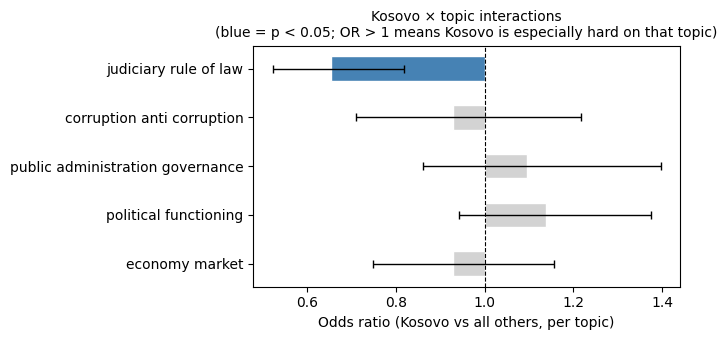

CHECK 3 — Severity ratio OLS (n = 17,833 paragraphs with soft criticism)

Topic & time:
                                    coef   CI_lo   CI_hi    pval
judiciary rule of law             0.0871  0.0481  0.1260  0.0000
corruption anti corruption        0.0420  0.0142  0.0697  0.0031
public administration governance -0.0002 -0.0263  0.0259  0.9872
political functioning             0.0226  0.0026  0.0427  0.0269
economy market                   -0.0288 -0.0486 -0.0091  0.0042
year trend                        0.0010 -0.0013  0.0034  0.3766

Country fixed effects (vs Albania):
                          coef   CI_lo   CI_hi  pval
Serbia                  0.0189  0.0158  0.0221   0.0
Ukraine                 0.0195  0.0134  0.0255   0.0
North Macedonia         0.0452  0.0433  0.0471   0.0
Moldova                 0.0470  0.0417  0.0524   0.0
Kosovo                  0.0613  0.0586  0.0639   0.0
Montenegro              0.0631  0.0584  0.0677   0.0
Georgia                 0.0698  0.0641  0.0754   

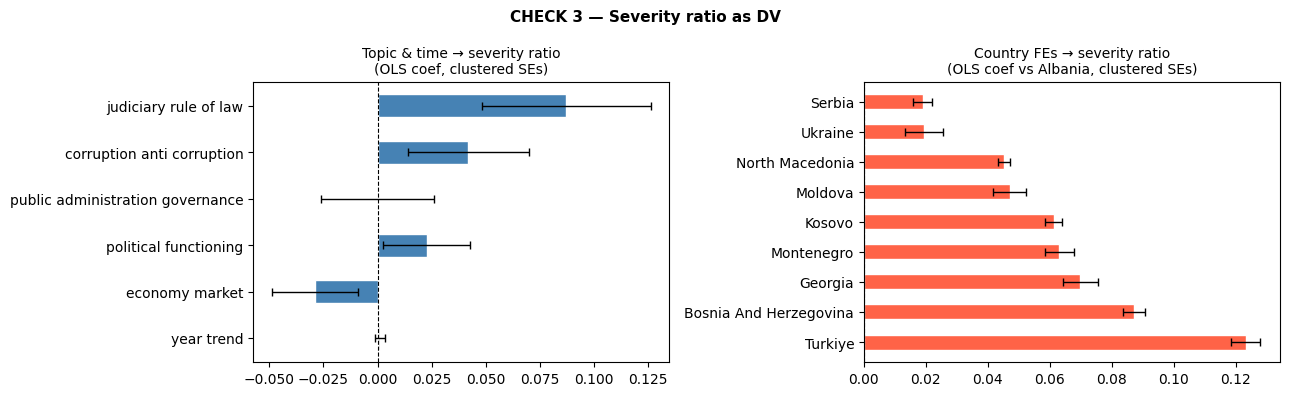

In [14]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ── shared setup (mirrors Step 6) ────────────────────────────────────────────
reg = df_scored.copy()
reg["hard_flag"] = (reg["criticism_hard_p1k"] > 0).astype(int)
topic_cols = [c for c in reg.columns if c.startswith("topic_")]
for c in topic_cols:
    reg[c] = reg[c].astype(int)
reg["year_c"]  = reg["year"] - reg["year"].median()
reg["kosovo"]  = (reg["country"] == "Kosovo").astype(int)
ref_country    = sorted(reg["country"].unique())[0]   # Albania
topic_terms    = " + ".join(topic_cols)
base_formula   = f"hard_flag ~ {topic_terms} + year_c + C(country, Treatment('{ref_country}'))"

def clean(s):
    return s.replace("topic_", "").replace("_", " ").replace("year c", "year trend")

# ════════════════════════════════════════════════════════════════════════════
# CHECK 1 — Clustered standard errors (cluster by country)
# ════════════════════════════════════════════════════════════════════════════
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_default  = smf.logit(base_formula, data=reg).fit(disp=False)
    model_cluster  = smf.logit(base_formula, data=reg).fit(
        disp=False, cov_type="cluster", cov_kwds={"groups": reg["country"]}
    )

mask_tt = pd.Series(model_default.params.index).str.startswith(("topic_", "year_c")).values

comp = pd.DataFrame({
    "OR":              np.exp(model_default.params[mask_tt]),
    "SE (default)":    model_default.bse[mask_tt],
    "SE (clustered)":  model_cluster.bse[mask_tt],
    "p (default)":     model_default.pvalues[mask_tt],
    "p (clustered)":   model_cluster.pvalues[mask_tt],
})
comp.index = [clean(i) for i in comp.index]
print("CHECK 1 — Clustered vs default SEs (topic & time terms)")
print(comp.round(3).to_string(), "\n")

# ════════════════════════════════════════════════════════════════════════════
# CHECK 2 — Kosovo × topic interactions
# ════════════════════════════════════════════════════════════════════════════
interact_terms = " + ".join([f"kosovo:{c}" for c in topic_cols])
formula_kos    = f"{base_formula} + {interact_terms}"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_kos = smf.logit(formula_kos, data=reg).fit(disp=False)

interact_idx = [i for i in model_kos.params.index if i.startswith("kosovo:")]
kos_res = pd.DataFrame({
    "OR":    np.exp(model_kos.params[interact_idx]),
    "CI_lo": np.exp(model_kos.conf_int().loc[interact_idx, 0]),
    "CI_hi": np.exp(model_kos.conf_int().loc[interact_idx, 1]),
    "pval":  model_kos.pvalues[interact_idx],
})
kos_res.index = [clean(i.replace("kosovo:", "")) for i in kos_res.index]
print("CHECK 2 — Kosovo × topic interaction terms (OR relative to other countries)")
print(kos_res.round(3).to_string(), "\n")

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["steelblue" if p < 0.05 else "lightgrey" for p in kos_res["pval"]]
ax.barh(kos_res.index, kos_res["OR"] - 1, left=1, color=colors, edgecolor="white", height=0.5)
ax.errorbar(
    kos_res["OR"], range(len(kos_res)),
    xerr=[kos_res["OR"] - kos_res["CI_lo"], kos_res["CI_hi"] - kos_res["OR"]],
    fmt="none", color="black", capsize=3, linewidth=1,
)
ax.axvline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Odds ratio (Kosovo vs all others, per topic)")
ax.set_title("Kosovo × topic interactions\n(blue = p < 0.05; OR > 1 means Kosovo is especially hard on that topic)", fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# CHECK 3 — Severity ratio as DV (OLS, clustered SEs)
# ════════════════════════════════════════════════════════════════════════════
import re

reg_sev     = reg[reg["severity_ratio"].notna()].copy()
formula_sev = f"severity_ratio ~ {topic_terms} + year_c + C(country, Treatment('{ref_country}'))"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_sev = smf.ols(formula_sev, data=reg_sev).fit(
        cov_type="cluster", cov_kwds={"groups": reg_sev["country"]}
    )

sev_res = pd.DataFrame({
    "coef":  model_sev.params,
    "CI_lo": model_sev.conf_int()[0],
    "CI_hi": model_sev.conf_int()[1],
    "pval":  model_sev.pvalues,
}).drop("Intercept")

mask_tt2 = sev_res.index.str.startswith(("topic_", "year_c"))
mask_c2  = sev_res.index.str.startswith("C(country")

def country_label(s):
    m = re.search(r"T\.(.+?)\]", s)
    return m.group(1) if m else s

print(f"CHECK 3 — Severity ratio OLS (n = {len(reg_sev):,} paragraphs with soft criticism)")

tt3 = sev_res[mask_tt2].copy()
tt3.index = [clean(i) for i in tt3.index]
print("\nTopic & time:")
print(tt3.round(4).to_string())

ct3 = sev_res[mask_c2].copy()
ct3.index = [country_label(i) for i in ct3.index]
ct3 = ct3.sort_values("coef")
print("\nCountry fixed effects (vs Albania):")
print(ct3.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tt3_plot  = tt3.copy()
colors_tt = ["steelblue" if p < 0.05 else "lightgrey" for p in tt3_plot["pval"]]
axes[0].barh(tt3_plot.index, tt3_plot["coef"], color=colors_tt, edgecolor="white", height=0.5)
axes[0].errorbar(
    tt3_plot["coef"], range(len(tt3_plot)),
    xerr=[tt3_plot["coef"] - tt3_plot["CI_lo"], tt3_plot["CI_hi"] - tt3_plot["coef"]],
    fmt="none", color="black", capsize=3, linewidth=1,
)
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Topic & time → severity ratio\n(OLS coef, clustered SEs)", fontsize=10)
axes[0].invert_yaxis()

ct3_plot  = ct3.copy()
colors_ct = ["tomato" if p < 0.05 else "lightgrey" for p in ct3_plot["pval"]]
axes[1].barh(ct3_plot.index, ct3_plot["coef"], color=colors_ct, edgecolor="white", height=0.5)
axes[1].errorbar(
    ct3_plot["coef"], range(len(ct3_plot)),
    xerr=[ct3_plot["coef"] - ct3_plot["CI_lo"], ct3_plot["CI_hi"] - ct3_plot["coef"]],
    fmt="none", color="black", capsize=3, linewidth=1,
)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Country FEs → severity ratio\n(OLS coef vs Albania, clustered SEs)", fontsize=10)
axes[1].invert_yaxis()

plt.suptitle("CHECK 3 — Severity ratio as DV", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 8 — Three-DV rigour test

Run the same specification with three different dependent variables side by side:
- **M1** `hard_flag` — does the paragraph contain *any* hard criticism? (logit)
- **M2** `soft_flag` — does the paragraph contain *any* soft criticism? (logit)
- **M3** `severity_ratio` — hard / soft ratio conditional on soft criticism existing (OLS)

Comparing M1 and M2 shows whether hard criticism is just a noisier version of soft, or a genuinely different signal. The scatter diagnostic then checks whether severity ratio is mechanically driven by the soft criticism rate (high soft denominator → deflated ratio).

Topics & time  (* p<.05  ** p<.01  *** p<.001)
                                 M1 hard_flag (OR) M2 soft_flag (OR) M3 severity_ratio (β)
judiciary rule of law                     1.867***           1.166**              0.087***
corruption anti corruption                1.581***          1.421***               0.042**
public administration governance            1.126*          1.290***                -0.000
political functioning                     1.304***           1.085**                0.023*
economy market                              0.880*             1.069              -0.029**
year trend                                   1.002            1.029*                 0.001 

Country fixed effects vs Albania  (sorted by M1 OR)
                       M1 hard_flag (OR) M2 soft_flag (OR) M3 severity_ratio (β)
Bosnia And Herzegovina          2.502***          1.395***              0.087***
Georgia                         1.602***          0.721***              0.070***
Kosovo             

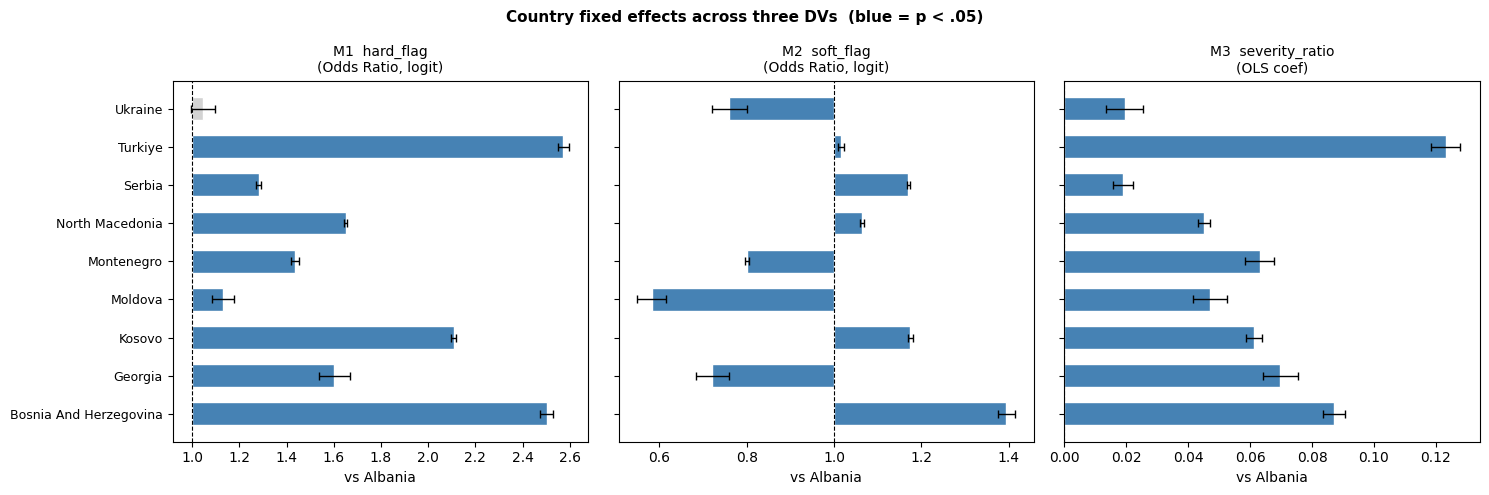

In [15]:
import warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ── shared setup ─────────────────────────────────────────────────────────────
reg = df_scored.copy()
reg["hard_flag"] = (reg["criticism_hard_p1k"] > 0).astype(int)
reg["soft_flag"] = (reg["criticism_soft_p1k"] > 0).astype(int)
topic_cols   = [c for c in reg.columns if c.startswith("topic_")]
for c in topic_cols:
    reg[c] = reg[c].astype(int)
reg["year_c"]  = reg["year"] - reg["year"].median()
ref_country    = sorted(reg["country"].unique())[0]   # Albania
topic_terms    = " + ".join(topic_cols)
rhs            = f"{topic_terms} + year_c + C(country, Treatment('{ref_country}'))"
cluster_kwds   = {"cov_type": "cluster", "cov_kwds": {"groups": reg["country"]}}

# ── fit three models ──────────────────────────────────────────────────────────
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    m1 = smf.logit(f"hard_flag ~ {rhs}", data=reg).fit(disp=False, **cluster_kwds)
    m2 = smf.logit(f"soft_flag ~ {rhs}", data=reg).fit(disp=False, **cluster_kwds)
    reg_sev = reg[reg["severity_ratio"].notna()].copy()
    m3 = smf.ols(f"severity_ratio ~ {rhs}", data=reg_sev).fit(
        cov_type="cluster", cov_kwds={"groups": reg_sev["country"]}
    )

def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

def extract_country_fe(model, exponentiate=True):
    idx = [i for i in model.params.index if i.startswith("C(country")]
    def label(s):
        m = re.search(r"T\.(.+?)\]", s)
        return m.group(1) if m else s
    vals = np.exp(model.params[idx]) if exponentiate else model.params[idx]
    pvals = model.pvalues[idx]
    return pd.Series(
        [f"{v:.3f}{stars(p)}" for v, p in zip(vals, pvals)],
        index=[label(i) for i in idx]
    )

def extract_topic_time(model, exponentiate=True):
    mask = pd.Series(model.params.index).str.startswith(("topic_", "year_c")).values
    vals  = np.exp(model.params[mask]) if exponentiate else model.params[mask]
    pvals = model.pvalues[mask]
    clean = lambda s: s.replace("topic_","").replace("_"," ").replace("year c","year trend")
    return pd.Series(
        [f"{v:.3f}{stars(p)}" for v, p in zip(vals, pvals)],
        index=[clean(i) for i in model.params.index[mask]]
    )

# ── topic & time table ────────────────────────────────────────────────────────
tt_table = pd.DataFrame({
    "M1 hard_flag (OR)":    extract_topic_time(m1, exponentiate=True),
    "M2 soft_flag (OR)":    extract_topic_time(m2, exponentiate=True),
    "M3 severity_ratio (β)": extract_topic_time(m3, exponentiate=False),
})
print("Topics & time  (* p<.05  ** p<.01  *** p<.001)")
print(tt_table.to_string(), "\n")

# ── country FE table ──────────────────────────────────────────────────────────
# Sort by M1 OR for consistent ordering
m1_order = (
    pd.Series(np.exp(m1.params[[i for i in m1.params.index if i.startswith("C(country")]]),
              index=[re.search(r"T\.(.+?)\]", i).group(1)
                     for i in m1.params.index if i.startswith("C(country")])
    .sort_values()
)
ct_table = pd.DataFrame({
    "M1 hard_flag (OR)":    extract_country_fe(m1),
    "M2 soft_flag (OR)":    extract_country_fe(m2),
    "M3 severity_ratio (β)": extract_country_fe(m3, exponentiate=False),
}).loc[m1_order.index]
print("Country fixed effects vs Albania  (sorted by M1 OR)")
print(ct_table.to_string(), "\n")

# ── side-by-side country FE plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
country_order = list(m1_order.index)

for ax, model, label, exp, ref in [
    (axes[0], m1, "M1  hard_flag\n(Odds Ratio, logit)", True,  1),
    (axes[1], m2, "M2  soft_flag\n(Odds Ratio, logit)", True,  1),
    (axes[2], m3, "M3  severity_ratio\n(OLS coef)",      False, 0),
]:
    idx  = [i for i in model.params.index if i.startswith("C(country")]
    labs = [re.search(r"T\.(.+?)\]", i).group(1) for i in idx]
    vals = np.exp(model.params[idx]) if exp else model.params[idx]
    pvs  = model.pvalues[idx]
    ci   = model.conf_int().loc[idx]
    cilo = np.exp(ci[0]) if exp else ci[0]
    cihi = np.exp(ci[1]) if exp else ci[1]

    order_map = {c: i for i, c in enumerate(country_order)}
    positions = [order_map[l] for l in labs]
    colors    = ["steelblue" if p < 0.05 else "lightgrey" for p in pvs]

    ax.barh(positions, vals - ref, left=ref, color=colors, edgecolor="white", height=0.6)
    ax.errorbar(vals, positions,
                xerr=[vals - cilo, cihi - vals],
                fmt="none", color="black", capsize=3, linewidth=1)
    ax.axvline(ref, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks(range(len(country_order)))
    ax.set_yticklabels(country_order, fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("vs Albania")

plt.suptitle("Country fixed effects across three DVs  (blue = p < .05)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


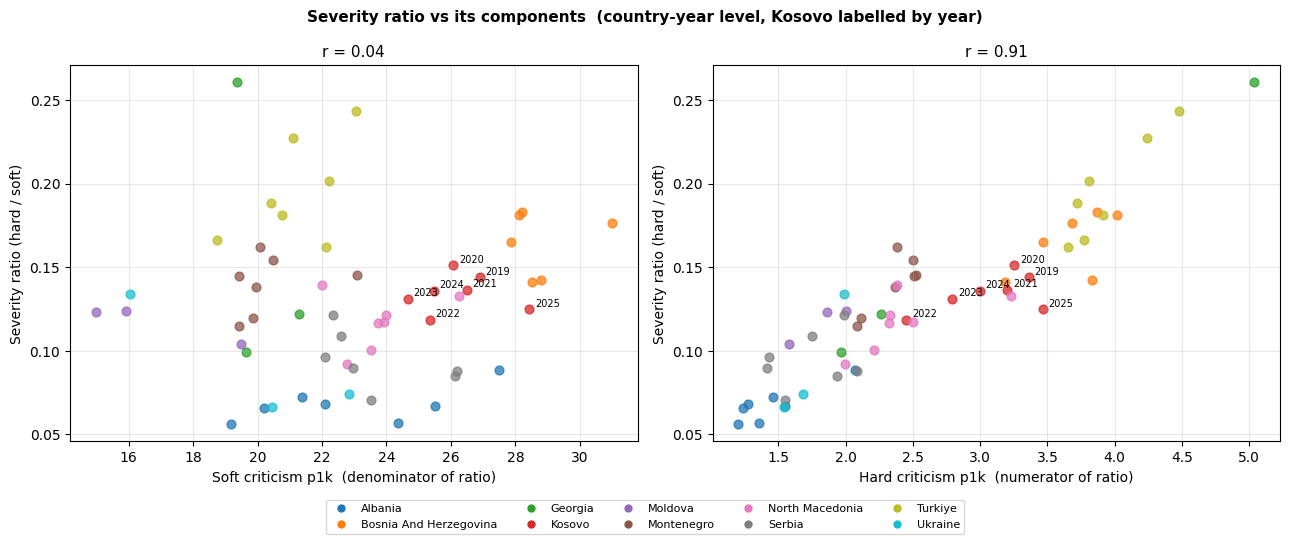

Correlations at country-year level:
                    criticism_hard_p1k  criticism_soft_p1k  severity_ratio
criticism_hard_p1k               1.000               0.316           0.913
criticism_soft_p1k               0.316               1.000           0.038
severity_ratio                   0.913               0.038           1.000


In [16]:
# ── Diagnostic: is severity ratio driven by soft criticism? ──────────────────
import matplotlib.cm as cm

colors_map = {c: cm.tab10(i / len(agg["country"].unique()))
              for i, c in enumerate(sorted(agg["country"].unique()))}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, xcol, xlabel in [
    (axes[0], "criticism_soft_p1k", "Soft criticism p1k  (denominator of ratio)"),
    (axes[1], "criticism_hard_p1k", "Hard criticism p1k  (numerator of ratio)"),
]:
    for country, grp in agg.groupby("country"):
        ax.scatter(grp[xcol], grp["severity_ratio"],
                   color=colors_map[country], label=country, alpha=0.75, s=40)

    # Annotate Kosovo points
    kos = agg[agg["country"] == "Kosovo"]
    for _, row in kos.iterrows():
        ax.annotate(str(int(row["year"])),
                    (row[xcol], row["severity_ratio"]),
                    fontsize=7, color="black",
                    xytext=(4, 2), textcoords="offset points")

    r = agg[[xcol, "severity_ratio"]].corr().iloc[0, 1]
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Severity ratio (hard / soft)", fontsize=10)
    ax.set_title(f"r = {r:.2f}", fontsize=11)
    ax.grid(True, alpha=0.3)

# Single legend outside
handles = [plt.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=colors_map[c], markersize=7, label=c)
           for c in sorted(agg["country"].unique())]
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.08))

plt.suptitle("Severity ratio vs its components  (country-year level, Kosovo labelled by year)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print("Correlations at country-year level:")
print(agg[["criticism_hard_p1k","criticism_soft_p1k","severity_ratio"]].corr().round(3).to_string())


### Step 8b — Alternative reference specifications

Two cleaner reference choices for the country fixed effects:
- **Deviation coding** (`Sum`) — each country coefficient is relative to the unweighted sample mean; no reference country needed
- **North Macedonia as reference** — a mid-pack Western Balkans EU candidate; coefficients read as "relative to a typical candidate country"

In [ ]:
import warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ── shared setup ──────────────────────────────────────────────────────────────
reg = df_scored.copy()
reg["hard_flag"] = (reg["criticism_hard_p1k"] > 0).astype(int)
reg["soft_flag"] = (reg["criticism_soft_p1k"] > 0).astype(int)
topic_cols = [c for c in reg.columns if c.startswith("topic_")]
for c in topic_cols:
    reg[c] = reg[c].astype(int)
reg["year_c"]    = reg["year"] - reg["year"].median()
topic_terms      = " + ".join(topic_cols)
cluster_kwds     = {"cov_type": "cluster", "cov_kwds": {"groups": reg["country"]}}
reg_sev          = reg[reg["severity_ratio"].notna()].copy()

def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

def fit_three(country_spec):
    rhs = f"{topic_terms} + year_c + {country_spec}"
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m1 = smf.logit(f"hard_flag ~ {rhs}", data=reg).fit(disp=False, **cluster_kwds)
        m2 = smf.logit(f"soft_flag ~ {rhs}", data=reg).fit(disp=False, **cluster_kwds)
        m3 = smf.ols(f"severity_ratio ~ {rhs}", data=reg_sev).fit(
            cov_type="cluster", cov_kwds={"groups": reg_sev["country"]}
        )
    return m1, m2, m3

def get_country_fe(model, exponentiate, label_fn):
    idx   = [i for i in model.params.index if "country" in i and "Intercept" not in i]
    vals  = np.exp(model.params[idx]) if exponentiate else model.params[idx]
    pvals = model.pvalues[idx]
    cilo  = np.exp(model.conf_int().loc[idx, 0]) if exponentiate else model.conf_int().loc[idx, 0]
    cihi  = np.exp(model.conf_int().loc[idx, 1]) if exponentiate else model.conf_int().loc[idx, 1]
    labels = [label_fn(i) for i in idx]
    return pd.DataFrame({"val": vals.values, "lo": cilo.values,
                         "hi": cihi.values, "p": pvals.values}, index=labels)

def plot_three(axes, models, country_order, ref_val, exponentiate, label_fn, title_suffix):
    model_labels = [
        f"M1  hard_flag\n(OR, logit)  {title_suffix}",
        f"M2  soft_flag\n(OR, logit)  {title_suffix}",
        f"M3  severity_ratio\n(OLS coef)  {title_suffix}",
    ]
    for ax, model, mlabel, exp in zip(axes, models,  model_labels,
                                      [exponentiate, exponentiate, False]):
        fe = get_country_fe(model, exp, label_fn)
        ref = 1 if exp else 0
        order_map = {c: i for i, c in enumerate(country_order)}
        present   = [c for c in country_order if c in fe.index]
        pos       = [order_map[c] for c in present]
        fe_sub    = fe.loc[present]
        colors    = ["steelblue" if p < 0.05 else "lightgrey" for p in fe_sub["p"]]
        ax.barh(pos, fe_sub["val"] - ref, left=ref, color=colors, edgecolor="white", height=0.6)
        ax.errorbar(fe_sub["val"], pos,
                    xerr=[fe_sub["val"] - fe_sub["lo"], fe_sub["hi"] - fe_sub["val"]],
                    fmt="none", color="black", capsize=3, linewidth=1)
        ax.axvline(ref, color="black", linewidth=0.8, linestyle="--")
        ax.set_yticks(range(len(country_order)))
        ax.set_yticklabels(country_order, fontsize=9)
        ax.set_title(mlabel, fontsize=9)

def print_fe_table(models, label_fn, exponentiate, title):
    def col(model, exp):
        fe = get_country_fe(model, exp, label_fn)
        return pd.Series(
            [f"{v:.3f}{stars(p)}" for v, p in zip(fe['val'], fe['p'])],
            index=fe.index
        )
    tbl = pd.DataFrame({
        "M1 hard_flag (OR)":     col(models[0], exponentiate),
        "M2 soft_flag (OR)":     col(models[1], exponentiate),
        "M3 severity_ratio (β)": col(models[2], False),
    })
    print(title)
    print(tbl.to_string(), "\n")

# ════════════════════════════════════════════════════════════════════════════
# SPEC A — Deviation coding (Sum): coefficients vs sample mean
# ════════════════════════════════════════════════════════════════════════════
models_sum = fit_three("C(country, Sum)")

def sum_label(s):
    m = re.search(r"Sum\]\[T\.(.+?)\]", s)
    return m.group(1) if m else s

# Sort by M1 hard_flag deviation
fe_m1_sum  = get_country_fe(models_sum[0], exponentiate=True, label_fn=sum_label)
sum_order  = fe_m1_sum["val"].sort_values().index.tolist()

print_fe_table(models_sum, sum_label, exponentiate=True,
               title="SPEC A — Deviation coding  (vs sample mean)  (* p<.05 ** p<.01 *** p<.001)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
plot_three(axes, models_sum, sum_order, ref_val=1,
           exponentiate=True, label_fn=sum_label, title_suffix="vs mean")
plt.suptitle("SPEC A — Deviation coding: country FEs relative to sample mean  (blue = p < .05)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# SPEC B — North Macedonia as reference country
# ════════════════════════════════════════════════════════════════════════════
models_nm = fit_three("C(country, Treatment('North Macedonia'))")

def nm_label(s):
    m = re.search(r"T\.(.+?)\]", s)
    return m.group(1) if m else s

fe_m1_nm  = get_country_fe(models_nm[0], exponentiate=True, label_fn=nm_label)
nm_order  = fe_m1_nm["val"].sort_values().index.tolist()

print_fe_table(models_nm, nm_label, exponentiate=True,
               title="SPEC B — North Macedonia as reference  (* p<.05 ** p<.01 *** p<.001)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
plot_three(axes, models_nm, nm_order, ref_val=1,
           exponentiate=True, label_fn=nm_label, title_suffix="vs N.Mac.")
plt.suptitle("SPEC B — Country FEs relative to North Macedonia  (blue = p < .05)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 9 — Unbalanced panel check + Serbia/Kosovo line chart

**Panel imbalance:** Georgia, Moldova, and Ukraine are only observed in 2023–2025; Bosnia from 2020. The remaining six countries (including Kosovo, Serbia, North Macedonia) have full 2019–2025 coverage. Country FEs for late-entry countries conflate "country effect" with "post-2022 period effect."

**Check:** Re-run Spec B restricted to 2023–2025 only — the one window where all countries overlap. If the Kosovo and Serbia FEs are stable relative to the full-sample Spec B, the imbalance is not driving results.

In [18]:
import warnings, re
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ── rebuild reg ───────────────────────────────────────────────────────────────
reg = df_scored.copy()
reg["hard_flag"] = (reg["criticism_hard_p1k"] > 0).astype(int)
reg["soft_flag"] = (reg["criticism_soft_p1k"] > 0).astype(int)
topic_cols = [c for c in reg.columns if c.startswith("topic_")]
for c in topic_cols:
    reg[c] = reg[c].astype(int)
reg["year_c"] = reg["year"] - reg["year"].median()
topic_terms   = " + ".join(topic_cols)
rhs_nm        = f"{topic_terms} + year_c + C(country, Treatment('North Macedonia'))"

def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

def fit_and_extract(data):
    reg_sev = data[data["severity_ratio"].notna()].copy()
    ck = {"cov_type": "cluster", "cov_kwds": {"groups": data["country"]}}
    ck_sev = {"cov_type": "cluster", "cov_kwds": {"groups": reg_sev["country"]}}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m1 = smf.logit(f"hard_flag ~ {rhs_nm}", data=data).fit(disp=False, **ck)
        m2 = smf.logit(f"soft_flag ~ {rhs_nm}", data=data).fit(disp=False, **ck)
        m3 = smf.ols(f"severity_ratio ~ {rhs_nm}", data=reg_sev).fit(**ck_sev)

    rows = {}
    for model, col, exp in [(m1, "M1 hard (OR)", True),
                             (m2, "M2 soft (OR)", True),
                             (m3, "M3 severity (β)", False)]:
        idx   = [i for i in model.params.index if "country" in i]
        vals  = np.exp(model.params[idx]) if exp else model.params[idx]
        pvs   = model.pvalues[idx]
        labs  = [re.search(r"T\.(.+?)\]", i).group(1) for i in idx]
        rows[col] = pd.Series(
            [f"{v:.3f}{stars(p)}" for v, p in zip(vals, pvs)], index=labs
        )
    return pd.DataFrame(rows)

# ── full sample (Spec B, reproduced for side-by-side) ────────────────────────
tbl_full = fit_and_extract(reg)

# ── restricted to 2023-2025 (common window) ───────────────────────────────────
reg_2023 = reg[reg["year"] >= 2023].copy()
reg_2023["year_c"] = reg_2023["year"] - reg_2023["year"].median()
tbl_2023 = fit_and_extract(reg_2023)

# ── side-by-side comparison ───────────────────────────────────────────────────
print(f"Full sample  n = {len(reg):,}  |  Restricted 2023-2025  n = {len(reg_2023):,}\n")
print("── Full sample (Spec B) ──────────────────────────────────────────")
print(tbl_full.to_string())
print()
print("── Restricted to 2023-2025 (all countries observed) ─────────────")
print(tbl_2023.to_string())


Full sample  n = 26,764  |  Restricted 2023-2025  n = 13,265

── Full sample (Spec B) ──────────────────────────────────────────
                       M1 hard (OR) M2 soft (OR) M3 severity (β)
Albania                    0.606***     0.939***       -0.045***
Bosnia And Herzegovina     1.515***     1.310***        0.042***
Georgia                       0.970     0.677***        0.025***
Kosovo                     1.277***     1.104***        0.016***
Moldova                    0.685***     0.547***           0.002
Montenegro                 0.870***     0.751***        0.018***
Serbia                     0.776***     1.100***       -0.026***
Turkiye                    1.559***     0.954***        0.078***
Ukraine                    0.633***     0.714***       -0.026***

── Restricted to 2023-2025 (all countries observed) ─────────────
                       M1 hard (OR) M2 soft (OR) M3 severity (β)
Albania                    0.559***     0.920***       -0.051***
Bosnia And Herzegovina  

In [ ]:
import warnings, re
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ── Countries with full 2019-2025 coverage ────────────────────────────────────
full_coverage = ["Albania", "Kosovo", "Montenegro", "North Macedonia", "Serbia", "Turkiye"]

reg_full = df_scored[df_scored["country"].isin(full_coverage)].copy()
reg_full["hard_flag"] = (reg_full["criticism_hard_p1k"] > 0).astype(int)
reg_full["soft_flag"] = (reg_full["criticism_soft_p1k"] > 0).astype(int)
topic_cols = [c for c in reg_full.columns if c.startswith("topic_")]
for c in topic_cols:
    reg_full[c] = reg_full[c].astype(int)
reg_full["year_c"] = reg_full["year"] - reg_full["year"].median()
topic_terms = " + ".join(topic_cols)
rhs_nm      = f"{topic_terms} + year_c + C(country, Treatment('North Macedonia'))"

def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

reg_sev = reg_full[reg_full["severity_ratio"].notna()].copy()
ck      = {"cov_type": "cluster", "cov_kwds": {"groups": reg_full["country"]}}
ck_sev  = {"cov_type": "cluster", "cov_kwds": {"groups": reg_sev["country"]}}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    m1 = smf.logit(f"hard_flag ~ {rhs_nm}", data=reg_full).fit(disp=False, **ck)
    m2 = smf.logit(f"soft_flag ~ {rhs_nm}", data=reg_full).fit(disp=False, **ck)
    m3 = smf.ols(f"severity_ratio ~ {rhs_nm}", data=reg_sev).fit(**ck_sev)

rows = {}
for model, col, exp in [(m1, "M1 hard (OR)", True),
                         (m2, "M2 soft (OR)", True),
                         (m3, "M3 severity (β)", False)]:
    idx  = [i for i in model.params.index if "country" in i]
    vals = np.exp(model.params[idx]) if exp else model.params[idx]
    pvs  = model.pvalues[idx]
    labs = [re.search(r"T\.(.+?)\]", i).group(1) for i in idx]
    rows[col] = pd.Series(
        [f"{v:.3f}{stars(p)}" for v, p in zip(vals, pvs)], index=labs
    )

tbl = pd.DataFrame(rows)
print(f"Spec B — North Macedonia reference | full-coverage countries only (n = {len(reg_full):,})")
print(f"Countries: {', '.join(full_coverage)}\n")
print(tbl.to_string())


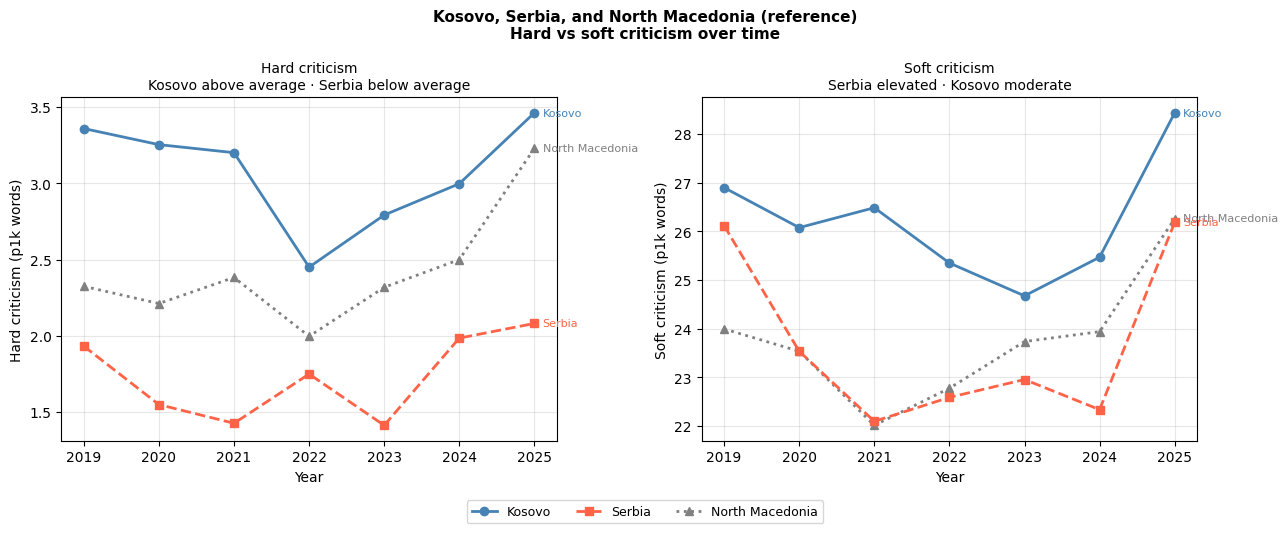

In [19]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ── Kosovo / Serbia / North Macedonia line chart ──────────────────────────────
focus      = ["Kosovo", "Serbia", "North Macedonia"]
styles     = {"Kosovo": ("steelblue", "o", "-"),
              "Serbia": ("tomato",    "s", "--"),
              "North Macedonia": ("grey", "^", ":")}

sub = agg[agg["country"].isin(focus)].sort_values("year")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

panels = [
    (axes[0], "criticism_hard_p1k", "Hard criticism (p1k words)",
     "Hard criticism\nKosovo above average · Serbia below average"),
    (axes[1], "criticism_soft_p1k", "Soft criticism (p1k words)",
     "Soft criticism\nSerbia elevated · Kosovo moderate"),
]

for ax, col, ylabel, title in panels:
    for country, grp in sub.groupby("country"):
        color, marker, ls = styles[country]
        ax.plot(grp["year"], grp[col],
                color=color, marker=marker, linestyle=ls,
                linewidth=2, markersize=6, label=country)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(sorted(sub["year"].unique()))
    ax.grid(True, alpha=0.3)

# Annotate 2025 endpoints
for country, grp in sub.groupby("country"):
    color, _, _ = styles[country]
    for col, ax in [(panels[0][1], axes[0]), (panels[1][1], axes[1])]:
        row = grp[grp["year"] == grp["year"].max()]
        if not row.empty:
            ax.annotate(country,
                        xy=(row["year"].values[0], row[col].values[0]),
                        xytext=(6, 0), textcoords="offset points",
                        fontsize=8, color=color, va="center")

# Legend
legend_handles = [
    mlines.Line2D([], [], color=c, marker=m, linestyle=ls, linewidth=2,
                  markersize=6, label=country)
    for country, (c, m, ls) in styles.items()
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.06))

plt.suptitle("Kosovo, Serbia, and North Macedonia (reference)\nHard vs soft criticism over time",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()
